# КИМ 6.1. Автокодировщики AE и VAE — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-06-autoencoders.ipynb`](./kim-06-autoencoders.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В решении используется **PyTorch** и датасет MNIST из `torchvision`.

Все модели небольшие и полносвязные. При `batch_size=512` полный последовательный
запуск рассчитан примерно на 5–15 минут в зависимости от CPU/GPU и скорости
загрузки MNIST. Числа метрик не зашиты в текст: они вычисляются при запуске.

---
## 0. Импорт, воспроизводимость и устройство

In [1]:
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import silhouette_score
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Для воспроизводимости на CUDA. Для полносвязных сетей потеря скорости невелика.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
started_at = time.perf_counter()
print(f"PyTorch: {torch.__version__}; device: {device}")

PyTorch: 2.5.1+cu121; device: cuda


Фиксация seed делает разбиение данных, начальные веса и сэмплирование
воспроизводимыми. Небольшие расхождения на разных версиях PyTorch и разных GPU
всё же возможны из-за реализации низкоуровневых операций.

## 1. Загрузка и разбиение MNIST

In [2]:
BATCH_SIZE = 512
NUM_WORKERS = min(2, os.cpu_count() or 1)

transform = transforms.ToTensor()  # [0, 255] -> float32 в [0, 1]
full_train = datasets.MNIST("data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("data", train=False, download=True, transform=transform)

train_set, val_set = random_split(
    full_train,
    [54_000, 6_000],
    generator=torch.Generator().manual_seed(SEED),
)

def make_loader(dataset, shuffle=False, seed=SEED):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=NUM_WORKERS > 0,
        generator=torch.Generator().manual_seed(seed),
    )

train_loader = make_loader(train_set, shuffle=True)
val_loader = make_loader(val_set)
test_loader = make_loader(test_set)

print(f"train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")
images, labels = next(iter(train_loader))
print("Форма батча до разворачивания:", images.shape, labels.shape)

train=54000, val=6000, test=10000


Форма батча до разворачивания: torch.Size([512, 1, 28, 28]) torch.Size([512])


---
## Часть А. AE и снижение размерности

Полносвязный AE получает вектор из 784 пикселей. Последний слой декодера имеет
`Sigmoid`, поэтому его выход, как и вход, лежит в `[0, 1]`. Латентный слой
оставлен линейным: это не ограничивает знак и диапазон координат вложения.

## 2. Архитектура 784 → 128 → 64 → 32 → 64 → 128 → 784

In [3]:
class DenseAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


ae = DenseAutoencoder(latent_dim=32).to(device)
print(ae)
print("Число обучаемых параметров:", sum(p.numel() for p in ae.parameters()))

DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Число обучаемых параметров: 222384


## 3. Настоящие циклы обучения и оценки

MSE усредняется по объектам и 784 пикселям. В обучающем цикле выполняются
`zero_grad → forward → loss → backward → step`; при валидации отключаются и
градиенты, и обучающий режим модели.

In [4]:
def prepare_images(images):
    return images.to(device, non_blocking=True).flatten(start_dim=1)


@torch.no_grad()
def evaluate_autoencoder(model, loader):
    model.eval()
    loss_sum = 0.0
    n_objects = 0
    for images, _ in loader:
        x = prepare_images(images)
        reconstructed = model(x)
        loss = F.mse_loss(reconstructed, x, reduction="mean")
        loss_sum += loss.item() * x.size(0)
        n_objects += x.size(0)
    return loss_sum / n_objects


def train_autoencoder(model, train_data, val_data, epochs, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": []}
    training_started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        n_objects = 0

        for images, _ in train_data:
            x = prepare_images(images)
            optimizer.zero_grad(set_to_none=True)
            reconstructed = model(x)
            loss = F.mse_loss(reconstructed, x, reduction="mean")
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * x.size(0)
            n_objects += x.size(0)

        train_mse = loss_sum / n_objects
        val_mse = evaluate_autoencoder(model, val_data)
        history["train"].append(train_mse)
        history["val"].append(val_mse)
        print(
            f"epoch {epoch:02d}/{epochs}: "
            f"train MSE={train_mse:.5f}, val MSE={val_mse:.5f}"
        )

    elapsed = time.perf_counter() - training_started
    print(f"Время обучения: {elapsed:.1f} с")
    return history


AE_EPOCHS = 10
history_ae = train_autoencoder(ae, train_loader, val_loader, AE_EPOCHS)
print(f"Test MSE: {evaluate_autoencoder(ae, test_loader):.5f}")

epoch 01/10: train MSE=0.09283, val MSE=0.06654


epoch 02/10: train MSE=0.06085, val MSE=0.05581


epoch 03/10: train MSE=0.04805, val MSE=0.04215


epoch 04/10: train MSE=0.03757, val MSE=0.03481


epoch 05/10: train MSE=0.03273, val MSE=0.03073


...

epoch 07/10: train MSE=0.02739, val MSE=0.02698


epoch 08/10: train MSE=0.02613, val MSE=0.02576


epoch 09/10: train MSE=0.02485, val MSE=0.02441


epoch 10/10: train MSE=0.02365, val MSE=0.02331
Время обучения: 67.4 с


Test MSE: 0.02274


## 4. Кривые обучения и восстановления

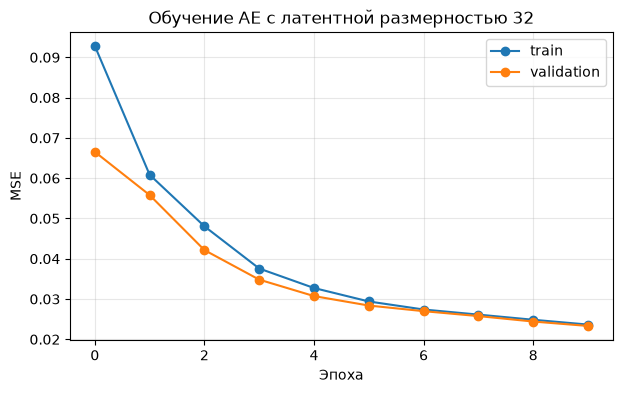

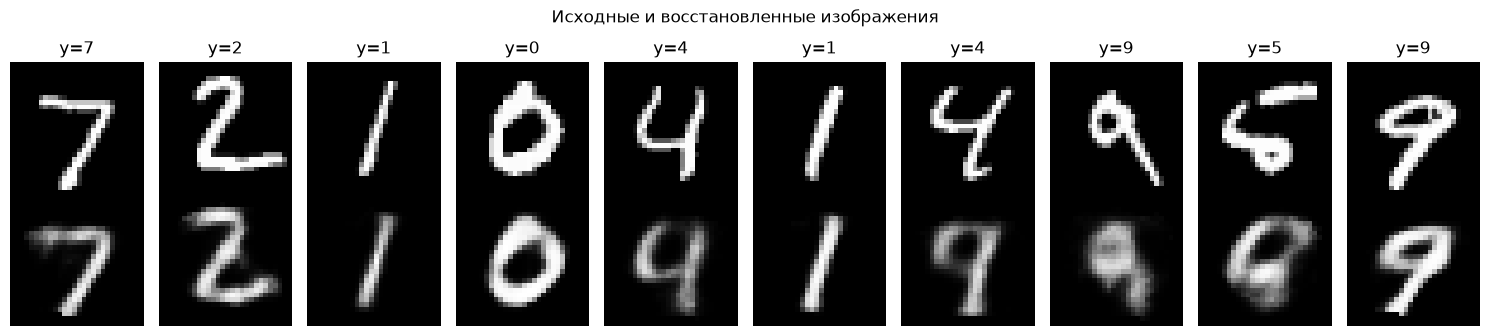

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(history_ae["train"], marker="o", label="train")
plt.plot(history_ae["val"], marker="o", label="validation")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение AE с латентной размерностью 32")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ae.eval()
images, labels = next(iter(test_loader))
x = prepare_images(images[:10])
with torch.no_grad():
    reconstructed = ae(x).cpu().reshape(-1, 28, 28)
originals = images[:10, 0]

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for i in range(10):
    axes[0, i].imshow(originals[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"y={labels[i].item()}")
    axes[1, i].imshow(reconstructed[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Оригинал")
axes[1, 0].set_ylabel("AE")
fig.suptitle("Исходные и восстановленные изображения")
plt.tight_layout()
plt.show()

MSE нужно интерпретировать вместе с изображениями: усреднение по
784 пикселям может скрывать размытые детали. Бутылочное горлышко из 32 чисел
сжимает вход примерно в 24.5 раза, но обычно сохраняет форму цифры и её наклон.

## 5. Двумерный AE и честное сравнение с PCA

Координаты 32-мерного AE нельзя просто назвать двумерным латентным пространством.
Поэтому обучим **отдельный** AE с теми же нелинейными слоями и `latent_dim=2`.
PCA обучается только на случайной части train, а обе проекции сравниваются на
одних и тех же тестовых объектах.

In [6]:
torch.manual_seed(SEED)
ae_2d = DenseAutoencoder(latent_dim=2).to(device)
AE2_EPOCHS = 15
history_ae_2d = train_autoencoder(ae_2d, train_loader, val_loader, AE2_EPOCHS)
print(f"2D AE test MSE: {evaluate_autoencoder(ae_2d, test_loader):.5f}")

epoch 01/15: train MSE=0.09176, val MSE=0.06272


epoch 02/15: train MSE=0.05851, val MSE=0.05551


epoch 03/15: train MSE=0.05450, val MSE=0.05344


epoch 04/15: train MSE=0.05292, val MSE=0.05222


epoch 05/15: train MSE=0.05147, val MSE=0.05057


...

epoch 12/15: train MSE=0.04520, val MSE=0.04520


epoch 13/15: train MSE=0.04480, val MSE=0.04490


epoch 14/15: train MSE=0.04440, val MSE=0.04451


epoch 15/15: train MSE=0.04412, val MSE=0.04425
Время обучения: 63.4 с


2D AE test MSE: 0.04412


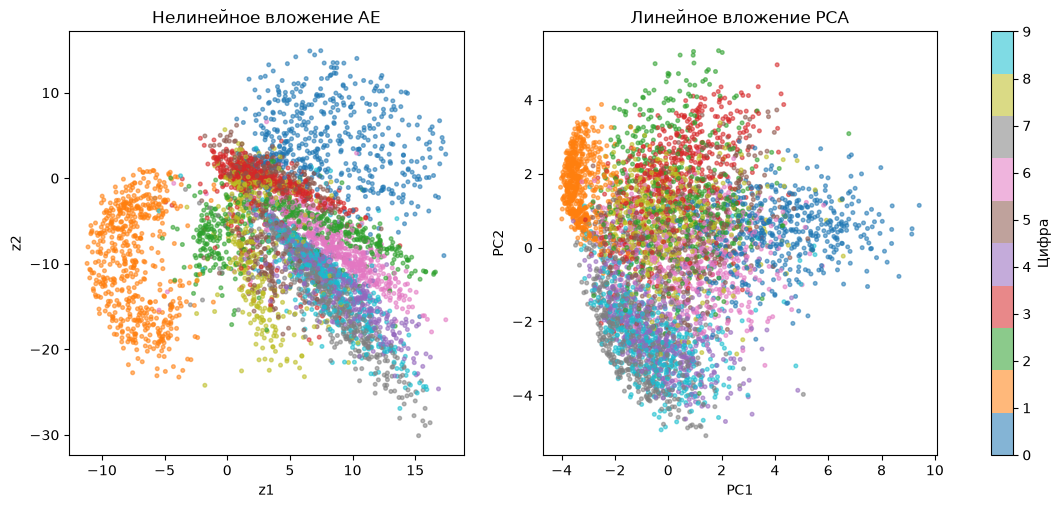

Silhouette: AE=-0.024, PCA=0.023
Доля дисперсии в двух компонентах PCA: 0.167


In [7]:
@torch.no_grad()
def collect_latents(model, loader):
    model.eval()
    latents, targets = [], []
    for images, labels in loader:
        z = model.encode(prepare_images(images))
        latents.append(z.cpu().numpy())
        targets.append(labels.numpy())
    return np.concatenate(latents), np.concatenate(targets)


z_ae, y_test = collect_latents(ae_2d, test_loader)

rng = np.random.default_rng(SEED)
pca_fit_indices = rng.choice(len(full_train), size=10_000, replace=False)
x_pca_train = (
    full_train.data[pca_fit_indices]
    .reshape(-1, 784)
    .numpy()
    .astype(np.float32)
    / 255.0
)
x_test_flat = (
    test_set.data.reshape(-1, 784).numpy().astype(np.float32) / 255.0
)
pca = PCA(n_components=2, svd_solver="randomized", random_state=SEED)
pca.fit(x_pca_train)
z_pca = pca.transform(x_test_flat)

# Ограничиваем только число нарисованных точек; метки и координаты согласованы.
viz_indices = rng.choice(len(test_set), size=5_000, replace=False)
y_viz = y_test[viz_indices]
z_ae_viz = z_ae[viz_indices]
z_pca_viz = z_pca[viz_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc_ae = axes[0].scatter(
    z_ae_viz[:, 0], z_ae_viz[:, 1], c=y_viz,
    cmap="tab10", s=7, alpha=0.55,
)
axes[0].set(title="Нелинейное вложение AE", xlabel="z1", ylabel="z2")
sc_pca = axes[1].scatter(
    z_pca_viz[:, 0], z_pca_viz[:, 1], c=y_viz,
    cmap="tab10", s=7, alpha=0.55,
)
axes[1].set(title="Линейное вложение PCA", xlabel="PC1", ylabel="PC2")
fig.colorbar(sc_pca, ax=axes, ticks=range(10), label="Цифра")
plt.show()

# Silhouette не является целью обучения AE, но даёт численное дополнение к графику.
ae_silhouette = silhouette_score(
    z_ae_viz, y_viz, sample_size=2_000, random_state=SEED,
)
pca_silhouette = silhouette_score(
    z_pca_viz, y_viz, sample_size=2_000, random_state=SEED,
)
print(f"Silhouette: AE={ae_silhouette:.3f}, PCA={pca_silhouette:.3f}")
print(
    "Доля дисперсии в двух компонентах PCA: "
    f"{pca.explained_variance_ratio_.sum():.3f}"
)

AE способен выучить нелинейную проекцию благодаря `ReLU`, тогда как
PCA ограничен линейной плоскостью максимальной дисперсии. Это **не гарантирует**,
что AE даст больший silhouette: обе модели оптимизируют восстановление, а не
разделение классов. Вывод следует делать по полученным картам, MSE и silhouette,
не по заранее ожидаемому победителю.

---
## Часть Б. Обнаружение аномалий

Считаем цифру 0 нормальным классом, остальные цифры — аномалиями. Новый AE не
увидит ни одной другой цифры при обучении. Порог выбирается по отдельной
валидационной части **только нормальных** данных; тестовые метки для выбора
порога не используются.

## 6. Нормальная train/validation выборка и обучение AE

In [8]:
zero_indices = torch.where(full_train.targets == 0)[0]
permutation = torch.randperm(
    len(zero_indices), generator=torch.Generator().manual_seed(SEED)
)
zero_indices = zero_indices[permutation]
split = int(0.85 * len(zero_indices))

zero_train_set = Subset(full_train, zero_indices[:split].tolist())
zero_val_set = Subset(full_train, zero_indices[split:].tolist())
zero_train_loader = make_loader(zero_train_set, shuffle=True, seed=SEED + 1)
zero_val_loader = make_loader(zero_val_set)

print(
    f"Только нули: train={len(zero_train_set)}, "
    f"validation={len(zero_val_set)}"
)

torch.manual_seed(SEED)
zero_ae = DenseAutoencoder(latent_dim=32).to(device)
ZERO_AE_EPOCHS = 25
history_zero = train_autoencoder(
    zero_ae, zero_train_loader, zero_val_loader, ZERO_AE_EPOCHS,
)

Только нули: train=5034, validation=889


epoch 01/25: train MSE=0.21709, val MSE=0.18491


epoch 02/25: train MSE=0.12179, val MSE=0.08140


epoch 03/25: train MSE=0.07475, val MSE=0.07063


epoch 04/25: train MSE=0.06784, val MSE=0.06736


...

epoch 21/25: train MSE=0.03987, val MSE=0.03970


epoch 22/25: train MSE=0.03897, val MSE=0.03882


epoch 23/25: train MSE=0.03821, val MSE=0.03792


epoch 24/25: train MSE=0.03746, val MSE=0.03731


epoch 25/25: train MSE=0.03678, val MSE=0.03651
Время обучения: 9.3 с


## 7. Ошибки, порог и precision/recall

Ошибка объекта — средний квадрат ошибки по его 784 пикселям. Берём 99-й
перцентиль ошибок нормальной validation-выборки: при совпадении будущего
распределения это задаёт около 1% ложных тревог на нормальных объектах. Такой
выбор не подглядывает в тест и явно задаёт допустимый false-positive rate.

Порог (99% normal validation) = 0.08362
Precision=0.998; Recall=0.364; F1=0.533
TN=975, FP=5, FN=5738, TP=3282
False-positive rate на тестовых нулях: 0.510%
Средняя MSE: нули=0.03700, остальные=0.08166


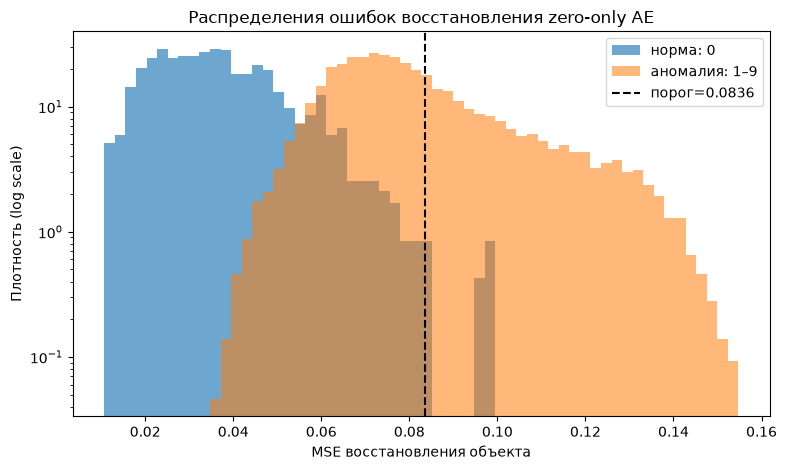

In [9]:
@torch.no_grad()
def reconstruction_errors(model, loader):
    model.eval()
    all_errors, all_labels = [], []
    for images, labels in loader:
        x = prepare_images(images)
        reconstructed = model(x)
        errors = (reconstructed - x).pow(2).mean(dim=1)
        all_errors.append(errors.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_errors), np.concatenate(all_labels)


normal_val_errors, _ = reconstruction_errors(zero_ae, zero_val_loader)
threshold_quantile = 0.99
threshold = np.quantile(normal_val_errors, threshold_quantile)

test_errors, test_labels = reconstruction_errors(zero_ae, test_loader)
true_anomaly = (test_labels != 0).astype(np.int64)
predicted_anomaly = (test_errors > threshold).astype(np.int64)

precision = precision_score(true_anomaly, predicted_anomaly, zero_division=0)
recall = recall_score(true_anomaly, predicted_anomaly, zero_division=0)
f1 = f1_score(true_anomaly, predicted_anomaly, zero_division=0)
tn, fp, fn, tp = confusion_matrix(true_anomaly, predicted_anomaly).ravel()

print(f"Порог ({threshold_quantile:.0%} normal validation) = {threshold:.5f}")
print(f"Precision={precision:.3f}; Recall={recall:.3f}; F1={f1:.3f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"False-positive rate на тестовых нулях: {fp / (fp + tn):.3%}")
print(
    f"Средняя MSE: нули={test_errors[true_anomaly == 0].mean():.5f}, "
    f"остальные={test_errors[true_anomaly == 1].mean():.5f}"
)

plt.figure(figsize=(9, 5))
histogram_bins = np.histogram_bin_edges(test_errors, bins=60)
plt.hist(
    test_errors[true_anomaly == 0], bins=histogram_bins, density=True,
    alpha=0.65, label="норма: 0",
)
plt.hist(
    test_errors[true_anomaly == 1], bins=histogram_bins, density=True,
    alpha=0.55, label="аномалия: 1–9",
)
plt.axvline(threshold, color="black", linestyle="--", label=f"порог={threshold:.4f}")
plt.yscale("log")
plt.xlabel("MSE восстановления объекта")
plt.ylabel("Плотность (log scale)")
plt.title("Распределения ошибок восстановления zero-only AE")
plt.legend()
plt.show()

На тесте аномалий примерно 90%, поэтому одна высокая precision ещё
не доказывает качество метода: важны также recall, F1, число FP и гистограмма.
Порог 99% консервативен к ложным тревогам. Если пропуск аномалии дороже, квантиль
можно уменьшить, но выбирать его всё равно следует без тестовых меток.

---
## Часть В. VAE и генерация

VAE имеет двумерное латентное пространство. Энкодер выдаёт `mu` и `log_var`, а
декодер получает случайный `z`. Два измерения позволяют непосредственно
нарисовать распределение кодов и равномерную сетку генераций.

## 8. VAE как пользовательский `nn.Module`

In [10]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder_backbone = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(128, latent_dim)
        self.log_var_head = nn.Linear(128, latent_dim)
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_backbone(x)
        return self.mu_head(h), self.log_var_head(h)

    def reparameterize(self, mu, log_var):
        eps = torch.randn_like(mu)
        return mu + torch.exp(0.5 * log_var) * eps

    def decode(self, z):
        return self.decoder_net(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var


torch.manual_seed(SEED)
vae = VAE(latent_dim=2).to(device)
print(vae)
print("Число обучаемых параметров:", sum(p.numel() for p in vae.parameters()))

VAE(
  (encoder_backbone): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=128, out_features=2, bias=True)
  (log_var_head): Linear(in_features=128, out_features=2, bias=True)
  (decoder_net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Число обучаемых параметров: 469268


Репараметризация записана как
`z = mu + exp(0.5 * log_var) * eps`, где `eps ~ N(0, I)`. Случайность вынесена
в `eps`, а преобразование относительно `mu` и `log_var` дифференцируемо, поэтому
градиент проходит в обе головы энкодера.

## 9. BCE + KL и ручной цикл `backward`

In [11]:
def vae_loss(reconstructed, x, mu, log_var):
    # Обе суммы делятся на batch size: получаем loss на один объект.
    batch_size = x.size(0)
    reconstruction = F.binary_cross_entropy(
        reconstructed, x, reduction="sum"
    ) / batch_size
    kl = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    ) / batch_size
    total = reconstruction + kl
    return total, reconstruction, kl


@torch.no_grad()
def evaluate_vae(model, loader):
    model.eval()
    sums = np.zeros(3, dtype=np.float64)
    n_objects = 0
    for images, _ in loader:
        x = prepare_images(images)
        reconstructed, mu, log_var = model(x)
        losses = vae_loss(reconstructed, x, mu, log_var)
        sums += np.array([value.item() for value in losses]) * x.size(0)
        n_objects += x.size(0)
    return sums / n_objects


optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
VAE_EPOCHS = 18
vae_history = {"train": [], "val": []}
vae_started = time.perf_counter()

for epoch in range(1, VAE_EPOCHS + 1):
    vae.train()
    train_sums = np.zeros(3, dtype=np.float64)
    n_objects = 0

    for images, _ in train_loader:
        x = prepare_images(images)
        optimizer.zero_grad(set_to_none=True)
        reconstructed, mu, log_var = vae(x)
        loss, reconstruction, kl = vae_loss(reconstructed, x, mu, log_var)
        loss.backward()
        optimizer.step()

        values = np.array([loss.item(), reconstruction.item(), kl.item()])
        train_sums += values * x.size(0)
        n_objects += x.size(0)

    train_losses = train_sums / n_objects
    val_losses = evaluate_vae(vae, val_loader)
    vae_history["train"].append(train_losses)
    vae_history["val"].append(val_losses)
    print(
        f"epoch {epoch:02d}/{VAE_EPOCHS}: "
        f"train total={train_losses[0]:.2f} "
        f"(BCE={train_losses[1]:.2f}, KL={train_losses[2]:.2f}); "
        f"val total={val_losses[0]:.2f} "
        f"(BCE={val_losses[1]:.2f}, KL={val_losses[2]:.2f})"
    )

print(f"Время обучения VAE: {time.perf_counter() - vae_started:.1f} с")

epoch 01/18: train total=237.65 (BCE=235.06, KL=2.59); val total=192.50 (BCE=190.18, KL=2.32)


epoch 02/18: train total=186.08 (BCE=182.90, KL=3.18); val total=178.84 (BCE=174.87, KL=3.97)


epoch 03/18: train total=174.92 (BCE=170.55, KL=4.37); val total=171.54 (BCE=166.77, KL=4.77)


epoch 04/18: train total=169.62 (BCE=164.74, KL=4.88); val total=167.43 (BCE=162.24, KL=5.19)


epoch 05/18: train total=166.20 (BCE=161.08, KL=5.12); val total=164.33 (BCE=159.07, KL=5.25)


...

epoch 14/18: train total=152.75 (BCE=146.91, KL=5.84); val total=152.60 (BCE=146.82, KL=5.79)


epoch 15/18: train total=152.01 (BCE=146.12, KL=5.88); val total=152.40 (BCE=146.45, KL=5.96)


epoch 16/18: train total=151.50 (BCE=145.58, KL=5.91); val total=151.73 (BCE=145.84, KL=5.89)


epoch 17/18: train total=150.82 (BCE=144.88, KL=5.94); val total=151.31 (BCE=145.30, KL=6.01)


epoch 18/18: train total=150.15 (BCE=144.18, KL=5.97); val total=150.67 (BCE=144.64, KL=6.03)
Время обучения VAE: 63.7 с


BCE суммируется по 784 пикселям, поэтому её численный масштаб больше,
чем у MSE из части А. KL имеет точную форму
`-0.5 * sum(1 + log_var - mu^2 - exp(log_var))`. Дополнительного коэффициента
`beta` здесь нет: оптимизируется стандартная нижняя вариационная граница.

## 10. Кривые loss и латентные средние VAE

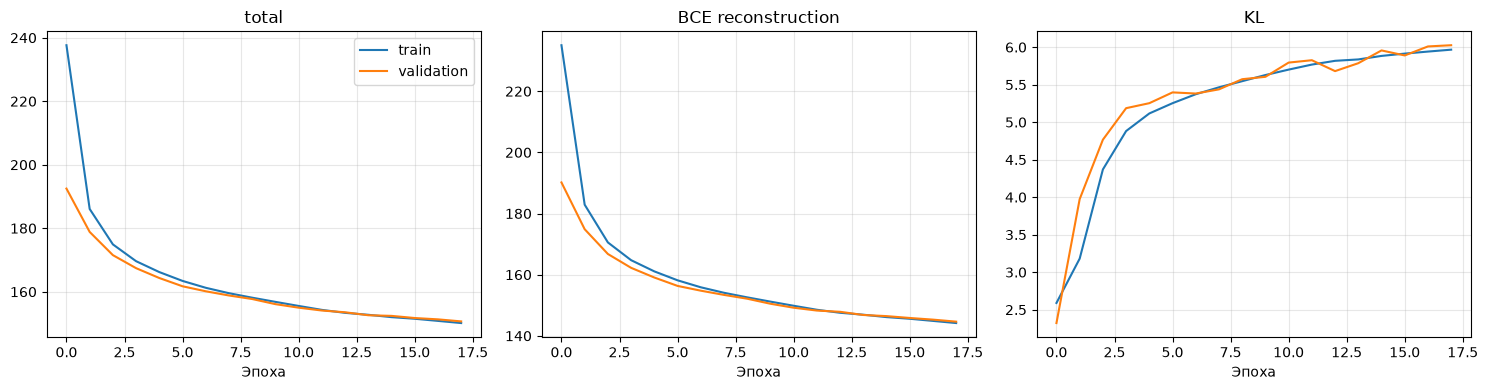

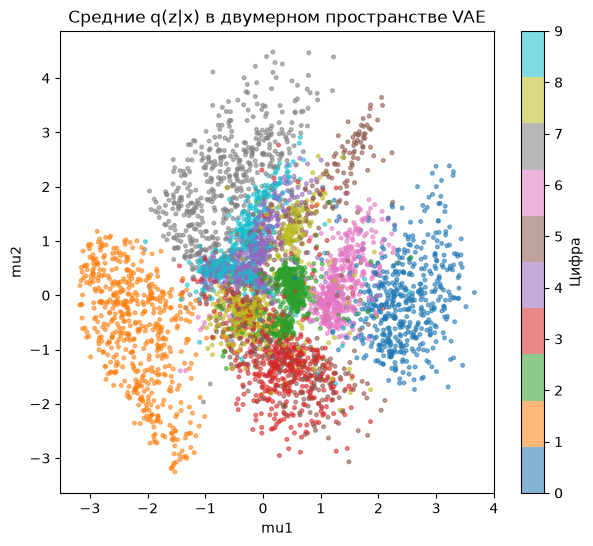

In [12]:
train_history = np.asarray(vae_history["train"])
val_history = np.asarray(vae_history["val"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = ["total", "BCE reconstruction", "KL"]
for i, name in enumerate(names):
    axes[i].plot(train_history[:, i], label="train")
    axes[i].plot(val_history[:, i], label="validation")
    axes[i].set_title(name)
    axes[i].set_xlabel("Эпоха")
    axes[i].grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

@torch.no_grad()
def collect_vae_means(model, loader):
    model.eval()
    means, targets = [], []
    for images, labels in loader:
        mu, _ = model.encode(prepare_images(images))
        means.append(mu.cpu().numpy())
        targets.append(labels.numpy())
    return np.concatenate(means), np.concatenate(targets)


vae_mu, vae_labels = collect_vae_means(vae, test_loader)
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    vae_mu[viz_indices, 0], vae_mu[viz_indices, 1],
    c=vae_labels[viz_indices], cmap="tab10", s=7, alpha=0.55,
)
plt.colorbar(scatter, ticks=range(10), label="Цифра")
plt.xlabel("mu1")
plt.ylabel("mu2")
plt.title("Средние q(z|x) в двумерном пространстве VAE")
plt.show()

## 11. Генерация сетки из двумерного пространства

После KL-регуляризации область около стандартного нормального распределения
заполнена кодами. Декодируем сетку из диапазона `[-2.5, 2.5]` сразу одним
батчем. Соседние клетки должны меняться плавно, а большая часть клеток в центре
должна напоминать рукописные цифры.

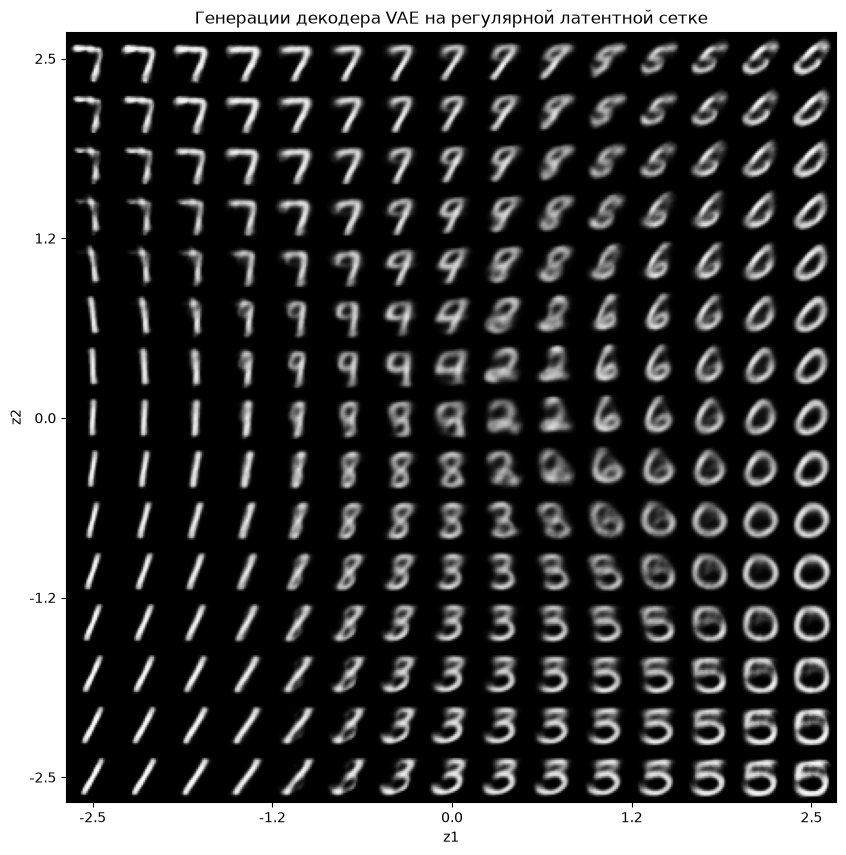

Полное время выполненных ячеек: 3.5 мин


In [13]:
vae.eval()
n = 15
grid_x = torch.linspace(-2.5, 2.5, n, device=device)
grid_y = torch.linspace(2.5, -2.5, n, device=device)
yy, xx = torch.meshgrid(grid_y, grid_x, indexing="ij")
z_grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

with torch.no_grad():
    generated = vae.decode(z_grid).cpu().reshape(n, n, 28, 28)

canvas = np.zeros((n * 28, n * 28), dtype=np.float32)
for row in range(n):
    for column in range(n):
        canvas[
            row * 28:(row + 1) * 28,
            column * 28:(column + 1) * 28,
        ] = generated[row, column].numpy()

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1)
tick_positions = np.linspace(14, n * 28 - 14, 5)
plt.xticks(tick_positions, [f"{x:.1f}" for x in np.linspace(-2.5, 2.5, 5)])
plt.yticks(tick_positions, [f"{y:.1f}" for y in np.linspace(2.5, -2.5, 5)])
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Генерации декодера VAE на регулярной латентной сетке")
plt.show()

print(f"Полное время выполненных ячеек: {(time.perf_counter() - started_at) / 60:.1f} мин")

---
## Итог

- **AE-32** даёт компактное детерминированное вложение и хорошие восстановления,
  но не задаёт распределение допустимых латентных точек.
- **AE-2 и PCA** решают задачу восстановления разными способами: AE допускает
  нелинейность, PCA строит линейную проекцию. Фактическое качество сравнивается
  по графикам, MSE и silhouette.
- **Zero-only AE** обнаруживает объекты вне обучающего распределения по MSE.
  Порог получен из normal validation, а не подобран по тестовым ответам.
- **VAE** платит за гладкое, пригодное для сэмплирования пространство слагаемым
  KL. Поэтому его восстановления могут быть более размытыми, зато декодирование
  точек из непрерывной 2D-сетки создаёт новые изображения.